# S-Channel Maze: Wavefront Optimization

Demonstrates **open eigenchannel routing** through a PEC cylinder maze.

An S-shaped channel is carved out of a dense array of PEC cylinders.
Normal incidence scatters off the walls, but the **SVD-optimal wavefront**
(last right singular vector of S11) finds the open channel and tunnels through.

**What this example demonstrates:**
1. Building a maze geometry with PEC cylinder walls
2. Normal incidence: most of the wave is reflected by the maze walls
3. Optimal wavefront: SVD of S11 reveals the open eigenchannel

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from scipy.special import hankel2 as hankel2_scipy

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.jax.smatrix import smatrix, _vall_batch
from Scattering_Code.jax.transall import transall
from Scattering_Code.jax.sall import sall
from Scattering_Code.jax.ky import ky

## 1. Build S-Channel Maze Geometry

Place PEC cylinders in a grid pattern with an S-shaped gap carved out.

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.0
RADIUS     = 0.2
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2

# Grid of cylinders
spacing = 0.6
nx_grid = int(PERIOD / spacing)
ny_grid = 20
thickness = ny_grid * spacing

# Generate grid positions
all_positions = []
for iy in range(ny_grid):
    for ix in range(nx_grid):
        x = (ix + 0.5) * spacing
        y = (iy + 0.5) * spacing
        all_positions.append([x, y])

all_positions = np.array(all_positions)

# Carve S-channel: remove cylinders within channel_width of the S-path
channel_width = 1.2

def s_channel_center(y, period, thickness):
    """S-shaped channel center x-position as function of y."""
    t = y / thickness  # normalize to [0, 1]
    return period/2 + (period/4) * np.sin(2 * np.pi * t)

keep = []
for pos in all_positions:
    x, y = pos
    cx = s_channel_center(y, PERIOD, thickness)
    if abs(x - cx) > channel_width / 2:
        keep.append(pos)

clocs = np.array(keep)
num_cyl = len(clocs)
print(f"Maze: {num_cyl} PEC cylinders, thickness = {thickness}")

Maze: 360 PEC cylinders, thickness = 12.0


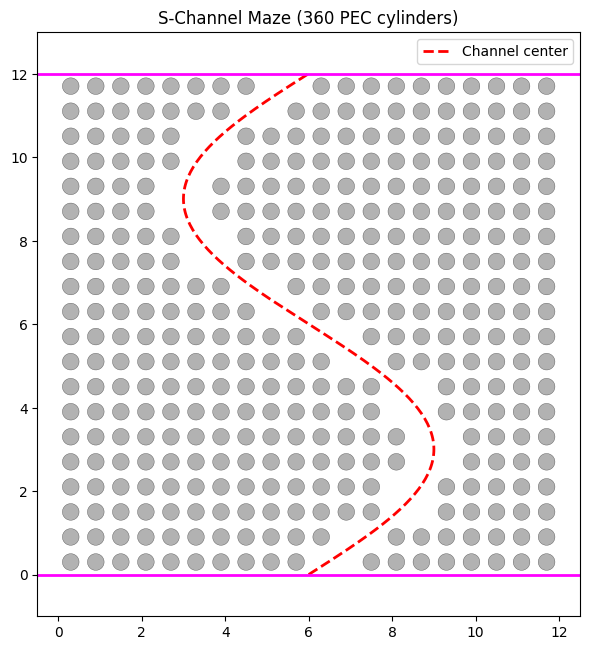

In [3]:
fig, ax = plt.subplots(figsize=(6, 10))
theta = np.linspace(0, 2*np.pi, 30)
for i in range(num_cyl):
    ax.fill(clocs[i,0] + RADIUS*np.cos(theta),
            clocs[i,1] + RADIUS*np.sin(theta),
            color='gray', alpha=0.6, edgecolor='black', lw=0.3)

# Draw S-channel path
y_path = np.linspace(0, thickness, 200)
x_path = s_channel_center(y_path, PERIOD, thickness)
ax.plot(x_path, y_path, 'r--', lw=2, label='Channel center')

ax.axhline(0, color='magenta', lw=2)
ax.axhline(thickness, color='magenta', lw=2)
ax.set_xlim(-0.5, PERIOD + 0.5)
ax.set_ylim(-1, thickness + 1)
ax.set_aspect('equal')
ax.set_title(f'S-Channel Maze ({num_cyl} PEC cylinders)')
ax.legend()
plt.tight_layout()
plt.savefig('s_channel_maze_geometry.png', dpi=150)
plt.show()

## 2. Compute S-Matrix

In [ ]:
nmax = int(np.floor(PERIOD / WAVELENGTH))  # PEC
nm   = 2 * nmax + 1

sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
cmmaxs = np.full(num_cyl, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(num_cyl, -1.0), np.full(num_cyl, MU)])
crads  = np.full(num_cyl, RADIUS)

print(f"Computing S-matrix ({num_cyl} cylinders, nmax={nmax})...")
t0 = time.time()
S, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH, nmax, thickness, sp, 'On')
S = np.array(S)
               
print(f"Done in {time.time()-t0:.1f}s")

Computing S-matrix (360 cylinders, nmax=12)...


/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/maze_s_matrix_wavefront_optimization/../../Scattering_Code/smatrix.py:52: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  clocs = jnp.asarray(clocs, dtype=jnp.float64)
/opt/anaconda3/lib/python3.13/site-packages/jax/_src/numpy/lax_numpy.py:5982: UserWarning: Explicitly requested dtype float64 requested in arange is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _arange(start, stop=stop, step=step, dtype=dtype,
/opt/anaconda3/lib/python3.13/site-packages/jax/_src/numpy/ar

  Computing T-Matrix...


W0414 10:28:14.225456 10893240 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/maze_s_matrix_wavefront_optimization/../../Scattering_Code/transall.py:56: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  clocs = jnp.asarray(clocs, dtype=jnp.float64)
/Users/thirulok/Documents/CyScat_Julia/CyScat/python_jax/CyScat/examples/maze_s_matrix_wavefront_optimization/../../Scattering_Code/bessel_jax.py:172: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option o

## 3. Compare Normal Incidence vs. Optimal Wavefront

In [ ]:
S11 = S[:nm, :nm]
S21 = S[nm:, :nm]

# Normal incidence
Input_norm = np.zeros(nm, dtype=complex)
Input_norm[nmax] = 1.0
T_norm = np.sum(np.abs(S21 @ Input_norm)**2)

# Optimal wavefront
U, s, Vh = svd(S11)
Input_opt = Vh.conj().T[:, -1]
T_opt = np.sum(np.abs(S21 @ Input_opt)**2)

# Transmission eigenvalues
tau = svd(S21, compute_uv=False)

print(f"Normal incidence transmission:  {T_norm*100:.2f}%")
print(f"Optimal wavefront transmission: {T_opt*100:.2f}%")
print(f"Enhancement factor: {T_opt/T_norm:.1f}x")
print(f"\nmax(tau^2) = {np.max(tau**2):.4f}")

Normal incidence transmission:  0.31%
Optimal wavefront transmission: 10.93%
Enhancement factor: 35.1x

max(tau^2) = 0.1093


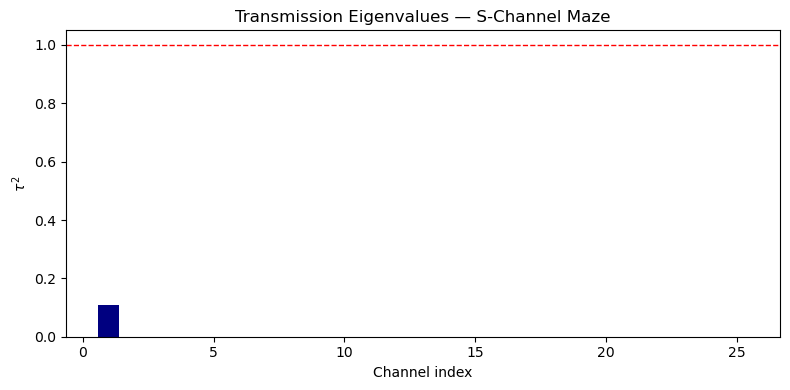

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(tau)+1), tau**2, color='navy')
ax.axhline(1.0, color='red', ls='--', lw=1)
ax.set_xlabel('Channel index')
ax.set_ylabel(r'$\tau^2$')
ax.set_title('Transmission Eigenvalues — S-Channel Maze')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('maze_singular_values.png', dpi=150)
plt.show()

## 4. Wave Field Visualization

Compute and visualize the wave field for both normal incidence and the optimal eigenchannel wavefront.

In [ ]:
# ── Precompute T-matrix once (shared across both field modes) ─────────────────
print("Precomputing T-matrix for field visualization...")
t0 = time.time()
_total_steps = len(cmmaxs) * (len(cmmaxs) - 1) // 2 + 2 * nm
_t_mat  = np.array(transall(clocs, cmmaxs, PERIOD, WAVELENGTH, sp['phiinc'], sp, _total_steps))
_s_vec  = np.array(sall(cmmaxs, cepmus, crads, WAVELENGTH))
_z      = np.eye(len(_s_vec)) - np.diag(_s_vec) @ _t_mat

k_field = 2 * np.pi / WAVELENGTH
_kxex_all = np.array([
    float(np.array(sp['kxs']).flatten()[sp['MiddleIndex'] + nin])
    for nin in range(-nmax, nmax + 1)
])
_V_up = np.array(_vall_batch(clocs, cmmaxs, _kxex_all, k_field, up_down=1))  # (tot, nm)
_starts = np.concatenate([[0], np.cumsum(2 * cmmaxs + 1)[:-1]])
print(f"  T-matrix done in {time.time()-t0:.1f}s")


def build_field_maze(S, nmax, thickness, mode='normal'):
    """
    Compute wave field using Hankel expansion from each cylinder.
    Interior field: incident Floquet modes + sum of Hankel expansions.
    Field is zero inside cylinder radii (PEC).
    Uses precomputed T-matrix LU factorization (_lu, _piv).
    """
    nm   = 2 * nmax + 1
    S11  = S[:nm, :nm]
    S21  = S[nm:, :nm]

    # ── Input wavefront ──────────────────────────────────────────────────────
    if mode == 'opt_trans':
        _, _, Vh = svd(S11)
        v_in  = Vh.conj().T[:, -1]
        tc    = np.sum(np.abs(S21 @ v_in)**2)
        label = f'Optimal Wavefront — {tc*100:.1f}% transmitted'
    else:
        v_in       = np.zeros(nm, dtype=complex)
        v_in[nmax] = 1.0
        tc         = np.sum(np.abs(S21[:, nmax])**2)
        label = f'Normal Incidence — {tc*100:.1f}% transmitted'

    # ── Floquet parameters ────────────────────────────────────────────────────
    k   = 2 * np.pi / WAVELENGTH
    m_f = np.arange(-nmax, nmax + 1)
    kxs = 2 * np.pi / PERIOD * m_f
    kys = ky(k, kxs.astype(complex))
    P1  = np.diag(1.0 / np.sqrt(kys / k))
    Inc_c = P1 @ v_in
    Ref_c = P1 @ (S11 @ v_in)
    Tra_c = P1 @ (S21 @ v_in)

    # ── Solve for per-cylinder scattering coefficients ────────────────────────
    v_excite = _s_vec * (_V_up @ v_in)          # diag(s) @ V @ Input
    c_vector = np.linalg.solve(_z, v_excite)

    # ── Build grid ────────────────────────────────────────────────────────────
    GRID_RES = 120
    PR_Y     = 3
    Ly       = PR_Y * WAVELENGTH
    y_full   = np.linspace(-Ly, thickness + Ly, GRID_RES * 2)
    x_phys   = np.linspace(0, PERIOD, GRID_RES)
    Field    = np.zeros((GRID_RES, len(y_full)), dtype=complex)
    num_cyl  = len(crads)

    for jy, y in enumerate(y_full):
        # Phase factors for all modes, vectorized over x: (Nx, nm)
        phase_x = np.exp(-1j * np.outer(x_phys, kxs))  # (Nx, nm)

        if y < 0:
            Field[:, jy] = (
                phase_x @ (Inc_c * np.exp(-1j * kys * y)) +
                phase_x @ (Ref_c * np.exp(+1j * kys * y))
            )
        elif y > thickness:
            Field[:, jy] = phase_x @ (Tra_c * np.exp(-1j * kys * (y - thickness)))
        else:
            # Incident Floquet modes
            field_slice = phase_x @ (Inc_c * np.exp(-1j * kys * y))  # (Nx,)

            # Hankel expansion from each cylinder, vectorized over x
            for i in range(num_cyl):
                dx = x_phys - clocs[i, 0]  # (Nx,)
                dy = float(y  - clocs[i, 1])
                r  = np.sqrt(dx**2 + dy**2)  # (Nx,)

                # Zero inside cylinder
                inside = r <= crads[i]

                theta  = np.arctan2(dy, dx)  # (Nx,)
                i0     = _starts[i]
                m_max_i = int(cmmaxs[i])

                for m_idx in range(-m_max_i, m_max_i + 1):
                    coeff   = c_vector[i0 + m_idx + m_max_i]
                    h2_vals = hankel2_scipy(m_idx, k * r)       # (Nx,) vectorized
                    field_slice += coeff * h2_vals * np.exp(1j * m_idx * theta)

                field_slice[inside] = 0.0

            Field[:, jy] = field_slice

    return Field, x_phys / WAVELENGTH, y_full / WAVELENGTH, label


print("Building normal incidence field...")
t0 = time.time()
F_norm, x_grid_w, y_grid_w, label_norm = build_field_maze(S, nmax, thickness, 'normal')
print(f"  {label_norm}  [{time.time()-t0:.1f}s]")

print("Building optimal wavefront field...")
t0 = time.time()
F_opt, _, _, label_opt = build_field_maze(S, nmax, thickness, 'opt_trans')
print(f"  {label_opt}  [{time.time()-t0:.1f}s]")


Precomputing T-matrix for field visualization...
  transall: 64620 pairs (61560 spectral, 3060 spatial [vectorized])
  T-matrix done in 71.8s
Building normal incidence field...
  Normal Incidence — 0.3% transmitted  [28.1s]
Building optimal wavefront field...
  Optimal Wavefront — 10.9% transmitted  [27.9s]


## 5. Static Wave Field Plot

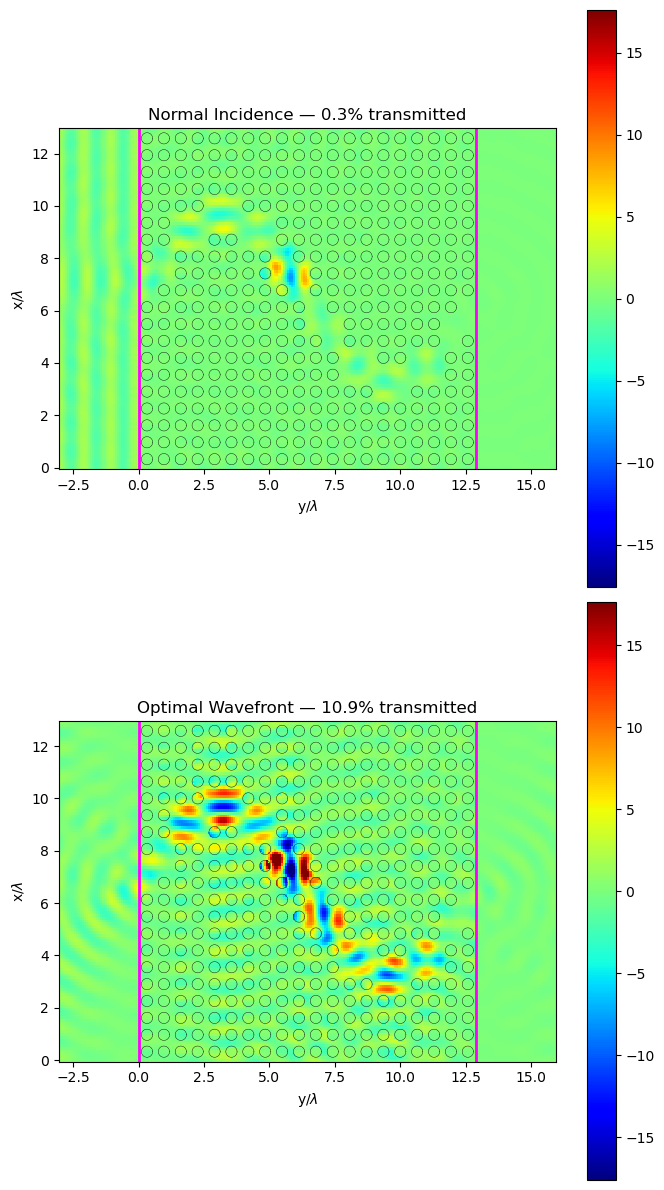

In [ ]:
vmax_w = max(np.max(np.abs(np.real(F_norm))), np.max(np.abs(np.real(F_opt)))) * 0.7
theta = np.linspace(0, 2 * np.pi, 30)

fig, axes = plt.subplots(2, 1, figsize=(7, 12))
for ax, F, label in zip(axes, [F_norm, F_opt], [label_norm, label_opt]):
    im = ax.pcolormesh(y_grid_w, x_grid_w, np.real(F), cmap='jet',
                       vmin=-vmax_w, vmax=vmax_w, shading='auto')
    ax.axvline(0, color='magenta', lw=2)
    ax.axvline(thickness / WAVELENGTH, color='magenta', lw=2)
    for i in range(num_cyl):
        cx = clocs[i, 1] / WAVELENGTH
        cy = clocs[i, 0] / WAVELENGTH
        r_lam = RADIUS / WAVELENGTH
        ax.plot(cx + r_lam * np.cos(theta), cy + r_lam * np.sin(theta), 'k-', lw=0.3)
    ax.set_xlabel(r'y/$\lambda$')
    ax.set_ylabel(r'x/$\lambda$')
    ax.set_title(label)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('maze_wave_field.png', dpi=150)
plt.show()


## 6. Wave Animation

Animate the wave field by sweeping phase over one full cycle.

In [ ]:
import matplotlib.animation as animation

N_FRAMES = 40
phases = np.linspace(0, 2 * np.pi, N_FRAMES, endpoint=False)
theta = np.linspace(0, 2 * np.pi, 30)

fig, axes = plt.subplots(2, 1, figsize=(7, 12))
vmax_anim = max(np.max(np.abs(F_norm)), np.max(np.abs(F_opt))) * 0.7

ims = []
for ax, F, label in zip(axes, [F_norm, F_opt], [label_norm, label_opt]):
    im = ax.pcolormesh(y_grid_w, x_grid_w, np.real(F), cmap='jet',
                       vmin=-vmax_anim, vmax=vmax_anim, shading='auto')
    ax.axvline(0, color='magenta', lw=2)
    ax.axvline(thickness / WAVELENGTH, color='magenta', lw=2)
    for i in range(num_cyl):
        cx = clocs[i, 1] / WAVELENGTH
        cy = clocs[i, 0] / WAVELENGTH
        r_lam = RADIUS / WAVELENGTH
        ax.plot(cx + r_lam * np.cos(theta), cy + r_lam * np.sin(theta), 'k-', lw=0.3)
    ax.set_xlabel(r'y/$\lambda$')
    ax.set_ylabel(r'x/$\lambda$')
    ax.set_title(label)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)
    ims.append(im)

plt.tight_layout()

def update(frame):
    phi = phases[frame]
    for im, F in zip(ims, [F_norm, F_opt]):
        im.set_array(np.real(F * np.exp(+1j * phi)))
    return ims

anim = animation.FuncAnimation(fig, update, frames=N_FRAMES, interval=80, blit=True)

print("Saving maze_wave_animation.mp4 ...")
anim.save('maze_wave_animation.mp4', writer='ffmpeg', fps=15, dpi=120)
print("Saved: maze_wave_animation.mp4")
plt.close(fig)


Saving maze_wave_animation.mp4 ...
Saved: maze_wave_animation.mp4
